# RNA para Regresión con Diabetes – Versión Mejorada (scikeras)

Versión completa usando `scikeras` en lugar de `tensorflow.keras.wrappers`:
1. Arquitectura mejorada + regularización L2.
2. Callbacks (EarlyStopping, ReduceLROnPlateau).
3. RandomizedSearchCV para hiperparámetros.
4. Comparación con RandomForestRegressor.

**Requisito**: instalar scikeras antes de ejecutar:
```bash
pip install scikeras[tensorflow]
```


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from tensorflow import keras
from tensorflow.keras import layers, regularizers

from scikeras.wrappers import KerasRegressor

import warnings
warnings.filterwarnings('ignore')


## 2. Cargar dataset y separar entrenamiento/validación


In [2]:
data = load_diabetes()
X = data.data
y = data.target

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)
print('Primeros 5 valores objetivo:', y[:5])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Entrenamiento:', X_train.shape, y_train.shape)
print('Validación:', X_val.shape, y_val.shape)


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores objetivo: [151.  75. 141. 206. 135.]
Entrenamiento: (353, 10) (353,)
Validación: (89, 10) (89,)


## 3. Estandarizar variables


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


## 4. Función para crear el modelo Keras


In [4]:
def build_model(n1=64, n2=32, lr=1e-3, l2_reg=1e-3):
    model = keras.Sequential([
        keras.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(n1, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dense(n2, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

build_model().summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks: EarlyStopping y ReduceLROnPlateau


In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_mae',
    patience=20,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=10,
    min_lr=1e-5
)

callbacks = [early_stop, reduce_lr]


## 6. KerasRegressor (scikeras) y RandomizedSearchCV


In [6]:
regressor = KerasRegressor(
    model=build_model,
    verbose=0
)

param_distrib = {
    'model__n1': [32, 64, 128],
    'model__n2': [16, 32, 64],
    'model__lr': [1e-2, 1e-3, 1e-4],
    'model__l2_reg': [1e-4, 1e-3, 1e-2],
    'batch_size': [8, 16, 32],
    'epochs': [200, 300]
}

random_search = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=param_distrib,
    n_iter=15,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42
)

random_search.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    callbacks=callbacks
)

print('Mejores hiperparámetros:')
print(random_search.best_params_)
print('Mejor score (neg MAE CV):', random_search.best_score_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores hiperparámetros:
{'model__n2': 32, 'model__n1': 64, 'model__lr': 0.001, 'model__l2_reg': 0.01, 'epochs': 200, 'batch_size': 32}
Mejor score (neg MAE CV): -44.539542974005734


## 7. Evaluar modelo final en validación


In [7]:
best_model = random_search.best_estimator_.model_

y_pred_val = best_model.predict(X_val_scaled).ravel()

mae_nn = mean_absolute_error(y_val, y_pred_val)
mse_nn = mean_squared_error(y_val, y_pred_val)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_val, y_pred_val)

print(f'MAE RNA mejorada: {mae_nn:.4f}')
print(f'MSE RNA mejorada: {mse_nn:.4f}')
print(f'RMSE RNA mejorada: {rmse_nn:.4f}')
print(f'R^2 RNA mejorada: {r2_nn:.4f}')


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
MAE RNA mejorada: 42.2818
MSE RNA mejorada: 2740.9895
RMSE RNA mejorada: 52.3545
R^2 RNA mejorada: 0.4827


## 8. Comparar con RandomForestRegressor


In [8]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_pred_rf)
mse_rf = mean_squared_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print(f'MAE RandomForest: {mae_rf:.4f}')
print(f'MSE RandomForest: {mse_rf:.4f}')
print(f'RMSE RandomForest: {rmse_rf:.4f}')
print(f'R^2 RandomForest: {r2_rf:.4f}')


MAE RandomForest: 44.5784
MSE RandomForest: 2998.3409
RMSE RandomForest: 54.7571
R^2 RandomForest: 0.4341


## 9. Gráfico y_val vs y_pred (RNA mejorada)


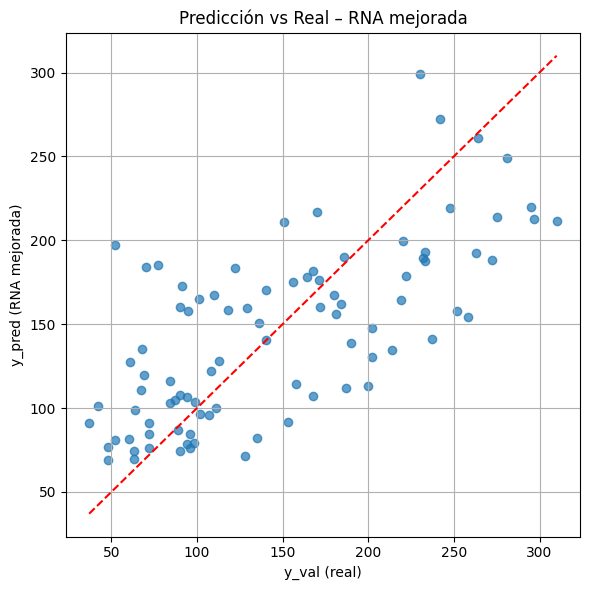

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred_val, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('y_val (real)')
plt.ylabel('y_pred (RNA mejorada)')
plt.title('Predicción vs Real – RNA mejorada')
plt.grid(True)
plt.tight_layout()
plt.show()
